In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
path = kagglehub.dataset_download("mabubakrsiddiq/students-learning-trajectory")
print("Path to dataset files:", path)

c:\Users\HANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HANIA\.cache\kagglehub\datasets\mabubakrsiddiq\students-learning-trajectory\versions\1


In [2]:
df = pd.read_csv(os.path.join(path, "student_learning_trajectory.csv"))
X = df[["study_hours","sleep_hours","stress_level","attendance_rate", "caffeine_intake"]].values
y = df[["performance_index"]].values

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=20
)

In [4]:
model = Sequential([
    Dense(128, activation = 'relu',input_shape=(5,), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),

    Dense(32, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.1),

    Dense(1)
])

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300


220/220 [==============================] - 2s 3ms/step - loss: 9688.7158 - mae: 98.2589 - val_loss: 9648.0156 - val_mae: 98.0626
Epoch 2/300
220/220 [==============================] - 0s 2ms/step - loss: 9151.0898 - mae: 95.4715 - val_loss: 8859.4395 - val_mae: 93.9506
Epoch 3/300
220/220 [==============================] - 0s 2ms/step - loss: 8423.9912 - mae: 91.5380 - val_loss: 7368.2466 - val_mae: 85.5496
Epoch 4/300
220/220 [==============================] - 0s 2ms/step - loss: 7504.6807 - mae: 86.2893 - val_loss: 6239.0972 - val_mae: 78.6700
Epoch 5/300
220/220 [==============================] - 0s 2ms/step - loss: 6432.5820 - mae: 79.7120 - val_loss: 5369.3809 - val_mae: 72.9600
Epoch 6/300
220/220 [==============================] - 0s 2ms/step - loss: 5262.0957 - mae: 71.8455 - val_loss: 4083.1272 - val_mae: 63.6000
Epoch 7/300
220/220 [==============================] - 0s 2ms/step - loss: 4106.6851 - mae: 63.1699 - val_loss: 3446.4680 - val_mae: 58.2341
Epoch 8/300

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_acc)

Test MSE: 22.174795150756836
Test MAE: 3.7325820922851562


<Axes: >

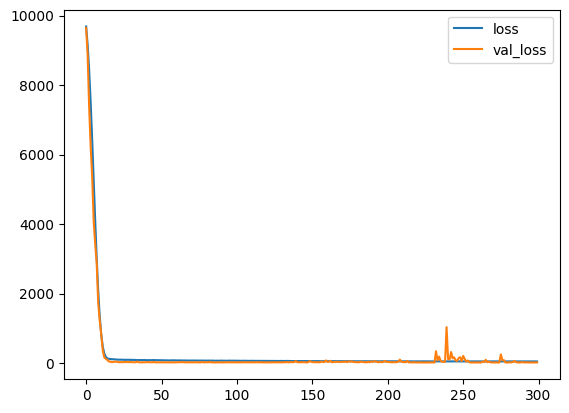

In [9]:
#Show the learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

In [10]:
model.save("advanced_model.h5")

c:\Users\HANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
